In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [6]:
stock = yf.download("AAPL", start="2020-01-01", end="2026-01-01")

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400543,72.460807,71.156704,71.409808,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


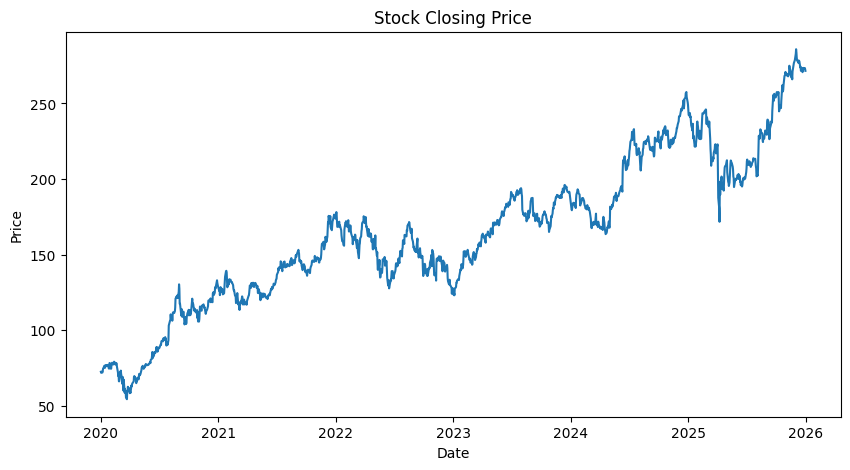

In [7]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [8]:
data = stock[['Close']]

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [10]:
X_train = []
y_train = []

for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i])
    y_train.append(scaled_data[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\91801\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0221
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.5530e-04
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9.1555e-04
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.8966e-04
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.0585e-04
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.7954e-04
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.4229e-04
Epoch 9/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.2902e-04
Epoch 10/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.7782e-04


In [13]:
test_data = scaled_data[-100:]

X_test = []
y_test = data[-40:].values

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i])

X_test = np.array(X_test)

In [14]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


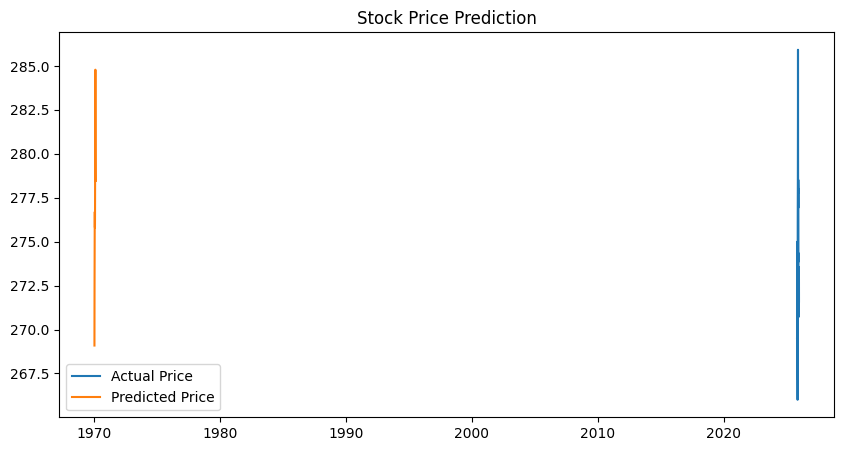

In [15]:
plt.figure(figsize=(10,5))

plt.plot(data[-40:], label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.legend()
plt.title("Stock Price Prediction")
plt.show()